Here, we preprocess the [immune dictionary](https://doi.org/10.1038/s41586-023-06816-9) dataset as described in scPerturb in anticipation that datasets from scPerturb will also be used. rds files are downloaded from the Immune Dictionary [download](https://www.immune-dictionary.org/app/home) page.

In [1]:
import os
from tqdm import tqdm

import scanpy as sc
import anndata as ad
from kneed import KneeLocator

import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import omnipath as op

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings(action='ignore', module='pandas')
warnings.filterwarnings(action='ignore', category=FutureWarning, module='ipykernel')
warnings.filterwarnings(action='ignore', category=FutureWarning, module='scanpy')
warnings.filterwarnings(action='ignore', category=UserWarning, module='scanpy')

import sys
sclembas_path = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas_path))
from scLEMBAS.preprocess import get_tf_activity, embed_tf_activity, transform_tf_activity, tf_to_adata
from scLEMBAS import io, preprocess

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

In [2]:
n_cores = 12
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'

In [3]:
quick_run = False # whether to subsample data and use quicker/less mem intensive (less accurate) versions of parameters

quick_dict = {'quick': {'perm': int(10), 'n_samples': int(1e3), 'batch_size': int(2e3)},
             'full': {'perm': int(1e3), 'n_samples': None, 'batch_size': int(1e4)}}
if quick_run: 
    run_key = 'quick'
else:
    run_key = 'full'


In [33]:
directory_names = [
    #data_path,
    #os.path.join(data_path, 'raw'), os.path.join(data_path, 'raw', 'immune_dictionary'),
    os.path.join(data_path, 'interim'), os.path.join(data_path, 'interim', 'immune_dictionary_h5ad'),
    os.path.join(data_path, 'processed'), os.path.join(data_path, 'figures')
]

for directory_name in directory_names:
    if not os.path.exists(directory_name):
        os.makedirs(directory_name)


# Load Files

In [5]:
data_path

'/nobackup/users/hmbaghda/scLEMBAS/analysis'

In [34]:
# h5ad_in_path = os.path.join(data_path, 'interim', 'immune_dictionary_h5ad')
# file_names = os.listdir(h5ad_in_path)

# imm_d = {}
# for file_name in file_names:
#     cell_type = file_name.split('ref_data_')[1].split('.h5ad')[0]
#     adata = sc.read_h5ad(os.path.join(h5ad_in_path, file_name)) # Seurat counts slot in adata.raw.X, data slot in adata.X
#     imm_d[cell_type] = adata
# adata = ad.concat(list(imm_d.values()),  join="outer")

# sco = sorted(adata.obs.seurat_clusters.unique())
# adata.obs.seurat_clusters = pd.Categorical(adata.obs.seurat_clusters,
#                                            categories=sco,
#                                            ordered=True)
# adata.write_h5ad(os.path.join(data_path, 'interim', 'id_all.h5ad'))
adata = sc.read_h5ad(os.path.join(data_path, 'interim', 'id_all.h5ad'))



In [18]:
if quick_run:
    adata = sc.pp.subsample(adata, n_obs = quick_dict[run_key]['n_samples'], copy = True, random_state = seed) 

First, we drop cells from reps 4-14. These are just PBS, and each of reps 1-3 have PBS controls:

In [35]:
retain_cells = adata.obs[~adata.obs.rep.isin(['rep' + str(i) for i in range(4,15)])].index.tolist()
adata = adata[retain_cells, :]

The paper has implemented a number of QC steps. However, they did not filter for cells with a minimum number of genes or genes present in a minimum number of cells. We will add this filter and reprocess according to the same protocol:

In [36]:
adata = adata.raw.to_adata()
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

Basic QC (mitochondrial genes, UMIs, multiplets) have already been applied from the paper and are not present in the dataset. Normalization is not identical to that done in the original immune dictionary, but very similar (1e5 scaling vs 1e6 CPM here).

In [37]:
adata.layers["counts"] = adata.X.copy() # store the raw data
sc.pp.normalize_total(adata, target_sum = 1e6)
sc.pp.log1p(adata)

Select HVGs:

From the methods section of the Immune Dictionary paper, it seems that batches are between replicate 1 and replicate 2/3. They indicate the experimental setup and downstream analysis mitigate batch effects. So, we will not do a batch correction for now. We've also excluded the PBS only replicates from the dataset. If doing one in the future, can either use the "rep" column or group replicates 2 and 3 together as one batch and corret against replicate 1. I mention this here because scanpy's HVG can do a "lightweight" batch correction by passing a batch key argument in the select highly variable genes. Again, for now, we don't worry about batches. 

In [10]:
sc.pp.highly_variable_genes(adata, n_top_genes=5000, batch_key=None, flavor = 'seurat')

Scale the data:

In [11]:
scaled_adata = sc.pp.scale(adata, copy = True)
adata.layers['scaled_data']  = scaled_adata.X.copy() # store the scaled data
del scaled_adata

Run dimensionality reduction:

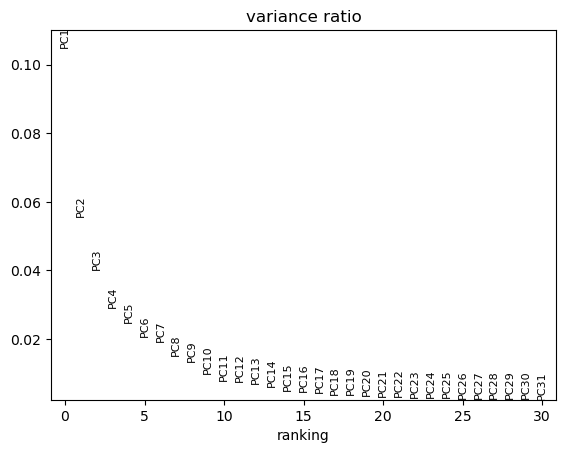

The elbow was automatically identified at PC 10


In [38]:
sc.tl.pca(adata, 
          zero_center = True, # rather than used scaled data, calculates covariance matrix internally
          n_comps = 50,
          random_state = seed, 
          use_highly_variable = True,
         )

variance_ratio = adata.uns['pca']['variance_ratio']
pcs = np.array(range(len(variance_ratio))) + 1
kneedle = KneeLocator(x = pcs, y = variance_ratio, curve='convex', direction='decreasing')
adata.uns['pca']['pca_rank'] = kneedle.elbow

sc.pp.neighbors(adata, n_pcs = adata.uns['pca']['pca_rank'])
sc.tl.umap(adata)

sc.tl.leiden(adata, flavor="igraph", n_iterations=2, 
             resolution = 2.5 # adjusted to be near the number of clusters identified by seurat by original paper
            )

adata.write_h5ad(os.path.join(data_path, 'interim', 'id_all_embedded.h5ad'))

adata = sc.read_h5ad(os.path.join(data_path, 'interim', 'id_all_embedded.h5ad'))


sc.pl.pca_variance_ratio(adata)
print('The elbow was automatically identified at PC {}'.format(adata.uns['pca']['pca_rank']))

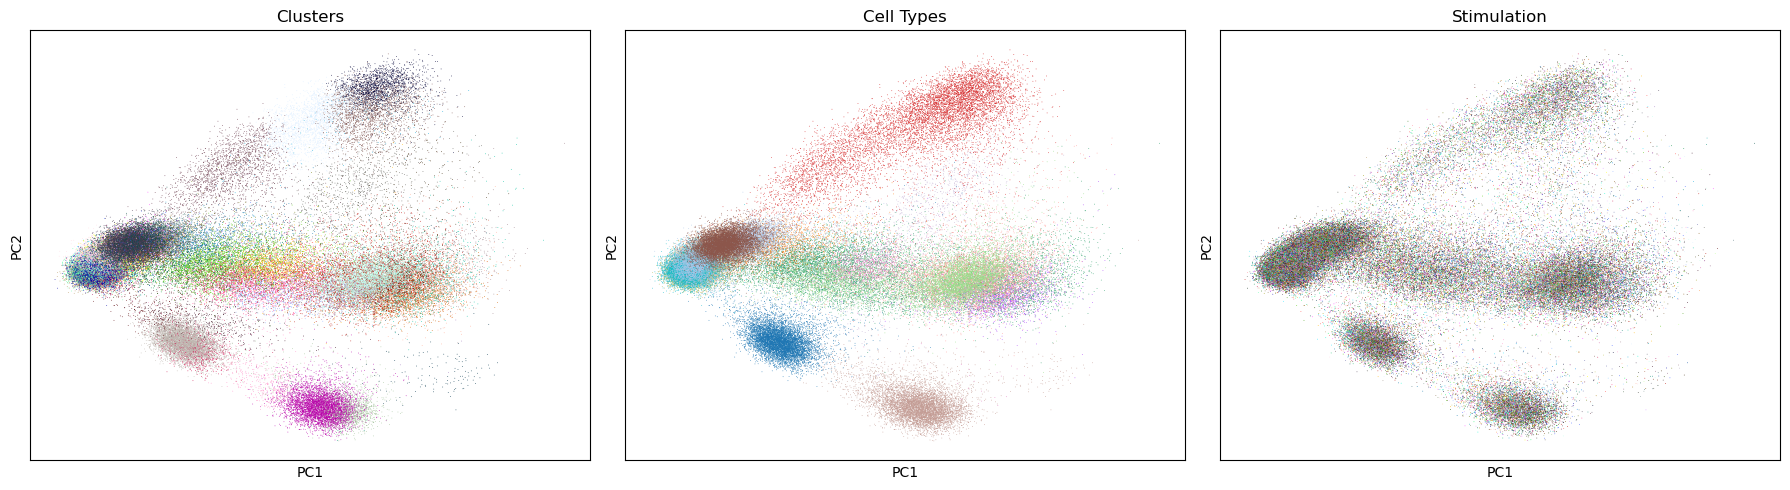

In [49]:
fig, ax = plt.subplots(ncols = 3, figsize = (18, 5))

sc.pl.pca(adata, color='leiden', ax = ax[0], show = False)
ax[0].set_title('Clusters')
ax[0].legend().set_visible(False)
# ax[0].legend(bbox_to_anchor=(-0.1, 1), ncol = 5, bbox_transform=ax[0].transAxes)

sc.pl.pca(adata, color='celltype', ax = ax[1], show = False)
ax[1].set_title('Cell Types')
ax[1].legend().set_visible(False)

sc.pl.pca(adata, color='sample', ax = ax[2], show = False)
ax[2].set_title('Stimulation')
ax[2].legend().set_visible(False)
# ax[2].annotate('NMI (TF Clusters, Cell Type):\n {:.2f}'.format(nmi(tf_adata.obs.TF_clusters, tf_adata.obs.celltype)),
#                 xy = (0.015, 0.9), xycoords='axes fraction', fontsize = 9)

fig.tight_layout()
plt.subplots_adjust(hspace=0.1)
plt.show()

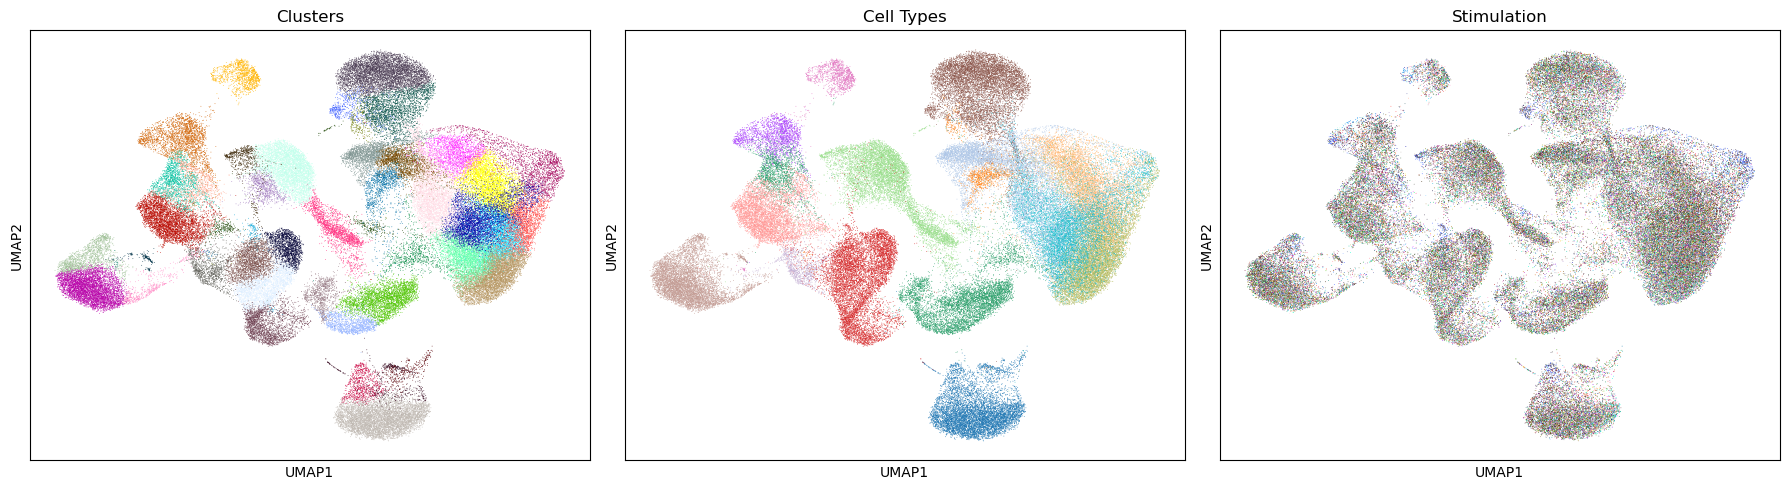

In [42]:
fig, ax = plt.subplots(ncols = 3, figsize = (18, 5))

sc.pl.umap(adata, color='leiden', ax = ax[0], show = False)
ax[0].set_title('Clusters')
ax[0].legend().set_visible(False)
# ax[0].legend(bbox_to_anchor=(-0.1, 1), ncol = 5, bbox_transform=ax[0].transAxes)

sc.pl.umap(adata, color='celltype', ax = ax[1], show = False)
ax[1].set_title('Cell Types')
ax[1].legend().set_visible(False)

sc.pl.umap(adata, color='sample', ax = ax[2], show = False)
ax[2].set_title('Stimulation')
ax[2].legend().set_visible(False)
# ax[2].annotate('NMI (TF Clusters, Cell Type):\n {:.2f}'.format(nmi(tf_adata.obs.TF_clusters, tf_adata.obs.celltype)),
#                 xy = (0.015, 0.9), xycoords='axes fraction', fontsize = 9)

fig.tight_layout()
plt.subplots_adjust(hspace=0.1)
plt.show()


# Get TF activity estimates:

In [39]:
kwargs = {'args' : {'wsum' : {'times': quick_dict[run_key]['perm'], 'batch_size': quick_dict[run_key]['batch_size']},
                       'ulm' : {'batch_size': quick_dict[run_key]['batch_size']}, 
                        'mlm': {'batch_size': quick_dict[run_key]['batch_size']}
                       }, 
#          'methods': ['wsum', 'ulm', 'mlm'], 
         'cns_metds': ['ulm_estimate', 'mlm_estimate', 'wsum_estimate']}
# default is wsum_norm, which introduces inf values that result in nan when z-scoring..
# also intuitively doesnt make sense to z-score an already normalized value
# particularly when the other z-scores or on the non-normalized values

adata = get_tf_activity(adata, organism = 'mouse', grn = 'collectri', verbose = True,
                consensus = True, hvg = True,
                min_n = 5, use_raw = False, filter_pvals = False, pval_thresh = 0.05, **kwargs)
adata.write_h5ad(os.path.join(data_path, 'processed', 'id_expr_scored.h5ad'))


adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'id_expr_scored.h5ad'))


Running scores.
Running mlm on mat with 94871 samples and 3000 targets for 409 sources.


100%|███████████████████████████████████████████| 10/10 [00:17<00:00,  1.71s/it]


Running ulm on mat with 94871 samples and 3000 targets for 409 sources.


100%|███████████████████████████████████████████| 10/10 [00:03<00:00,  3.11it/s]


Running wsum on mat with 94871 samples and 3000 targets for 409 sources.


100%|██████████████████████████████████████████| 10/10 [49:52<00:00, 299.22s/it]


Text(0.65, 0.9, 'Sparsity: 0.959')

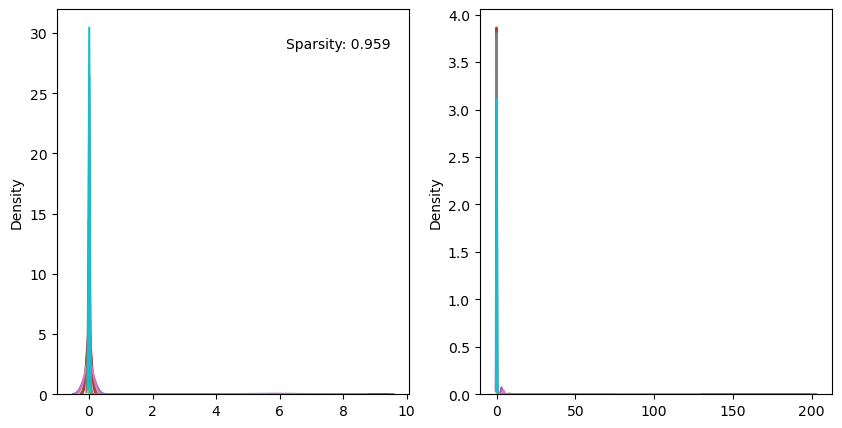

In [42]:
fig, ax = plt.subplots(ncols = 2, figsize = (10,5))

adata_ = adata[:, adata.var[adata.var['highly_variable']].index]
expr = adata_.to_df()
sparsity = (expr == 0).sum().sum() / expr.size

scaled_adata = sc.pp.scale(adata_, copy = True)
scaled_expr = scaled_adata.to_df()

subset = 10
np.random.seed(seed)
select_features = np.random.choice(expr.columns.tolist(), replace = False, size = 10)
# select_features = np.random.choice(adata.var['highly_variable'].index.tolist(), replace = False, size = 10)


for feature in select_features:
    sns.kdeplot(expr[feature].values, ax = ax[0])
    sns.kdeplot(scaled_expr[feature].values, ax = ax[1])
ax[0].annotate('Sparsity: {:.3f}'.format(sparsity), 
              xy = (0.65, 0.9), xycoords = 'axes fraction')

''

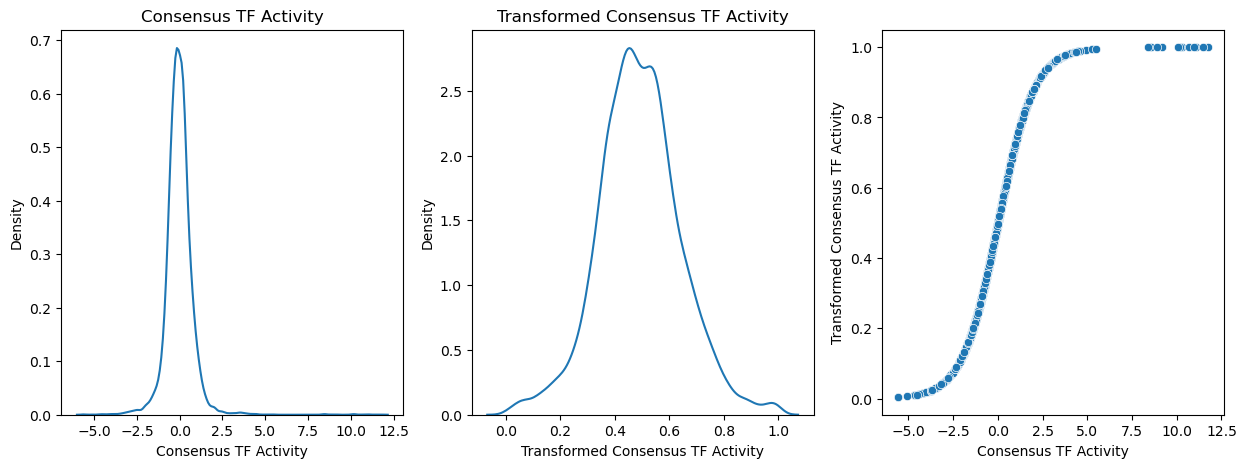

In [24]:
fig, ax = plt.subplots(ncols = 3, figsize = (15,5))

vals = adata.obsm['consensus_estimate'].values.flatten()
vals_transformed = transform_tf_activity(adata.obsm['consensus_estimate']).values.flatten()
scores = pd.DataFrame(data = {'Consensus TF Activity': vals, 
                    'Transformed Consensus TF Activity': vals_transformed})
scores_subset = scores.sample(n=int(1e4), random_state=seed)


sns.kdeplot(scores_subset['Consensus TF Activity'], ax = ax[0])
ax[0].set_title('Consensus TF Activity')

sns.kdeplot(scores_subset['Transformed Consensus TF Activity'], ax = ax[1])
ax[1].set_title('Transformed Consensus TF Activity')

sns.scatterplot(data = scores_subset, x = 'Consensus TF Activity', 
                y = 'Transformed Consensus TF Activity', ax = ax[2])
;

In [26]:
adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'id_expr_scored.h5ad'))
fn_csv = os.path.join(data_path, 'interim', 'id_TF_activity.csv') 
for key in adata.obsm:
    if key.endswith('estimate') or key.endswith('pvals'):
        fn_csv_ = fn_csv.replace('TF_activity', key + '_TF_activity')
        adata.obsm[key].to_csv(fn_csv_)

#         if key == 'consensus_estimate':
#             transformed_consensus = transform_tf_activity(adata.obsm[key])

# adata.obsm['consensus_estimate_transformed'] = transformed_consensus
tf_adata = tf_to_adata(adata, estimate_key = 'consensus_estimate')

io.write_tfad(tf_adata, file_name = os.path.join(data_path, 'interim', 'ID_tf_activity.h5ad'))